In [40]:
img_path= 'DukeData/train/images/Subject_02_01.npy'

In [41]:
import numpy as np
import matplotlib.pyplot as plt

In [42]:
img = np.load(img_path)

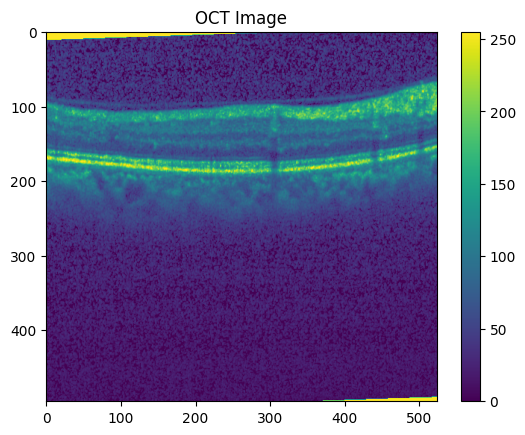

In [43]:
plt.imshow(img)
plt.title("OCT Image")
plt.colorbar()
plt.show()

In [7]:
"""pip install opencv-python"""

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [44]:
from sklearn.cluster import KMeans


pixels = img.flatten().reshape(-1, 1) # Flatten image for clustering
kmeans = KMeans(n_clusters=2).fit(pixels)
segmented_labels = kmeans.labels_.reshape(img.shape)

# Extract ROI and background based on cluster labels
roi = img[segmented_labels == 1]
background = img[segmented_labels == 0]


/home/parsar0000/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


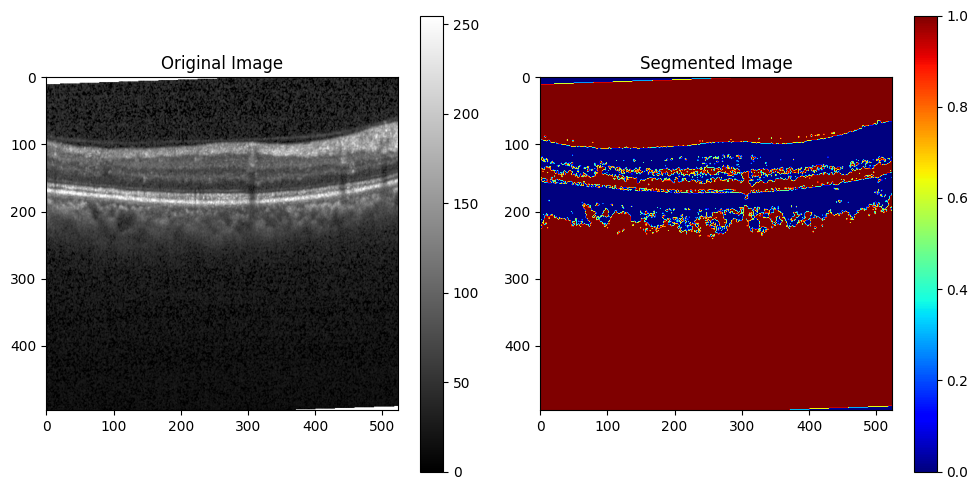

In [45]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.colorbar()

#
plt.subplot(1, 2, 2)
plt.imshow(segmented_labels, cmap='jet')
plt.title('Segmented Image')
plt.colorbar()

plt.tight_layout()
plt.show()

In [38]:
import os
import numpy as np
from sklearn.cluster import KMeans


folder_path = 'DukeData/train/images'


output_file = "cnr_results.txt"


cnr_results = []

# Iterate through all files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith(".npy"):
        file_path = os.path.join(folder_path, file_name)

        img = np.load(file_path)
        print(f"Processing {file_name}...")
        # Flatten image for clustering
        pixels = img.flatten().reshape(-1, 1)

        kmeans = KMeans(n_clusters=2, n_init=10, random_state=42).fit(pixels)
        segmented_labels = kmeans.labels_.reshape(img.shape)

        roi = img[segmented_labels == 1]
        background = img[segmented_labels == 0]

        S1 = np.mean(roi)
        S2 = np.mean(background)

        # Calculate noise (standard deviation of background)
        back_sigma = np.std(background)
        roi_sigma = np.std(roi)


        if back_sigma != 0 or roi_sigma!=0:  # Avoid division by zero
            CNR = abs(S1 - S2) / np.sqrt(roi_sigma**2 + back_sigma**2)
        else:
            CNR = float('inf')  # Assign infinity if sigma is 0

        cnr_results.append((file_name, CNR))

        print(f"File: {file_name}, CNR: {CNR}")


with open(output_file, "w") as f:
    f.write("File Name\tCNR\n")
    for file_name, CNR in cnr_results:
        f.write(f"{file_name}\t{CNR:.4f}\n")

print(f"CNR calculations completed. Results saved to {output_file}.")


Processing Subject_04_10.npy...
File: Subject_04_10.npy, CNR: 1.922178537499621
Processing Subject_06_09.npy...
File: Subject_06_09.npy, CNR: 3.0436059892549325
Processing Subject_04_08.npy...
File: Subject_04_08.npy, CNR: 2.307400675996248
Processing Subject_06_05.npy...
File: Subject_06_05.npy, CNR: 1.5517204861344067
Processing Subject_05_07.npy...
File: Subject_05_07.npy, CNR: 1.8887207152769623
Processing Subject_04_00.npy...
File: Subject_04_00.npy, CNR: 3.8629046666879225
Processing Subject_05_00.npy...
File: Subject_05_00.npy, CNR: 1.9252334473200425
Processing Subject_01_09.npy...
File: Subject_01_09.npy, CNR: 13.95176311455698
Processing Subject_06_00.npy...
File: Subject_06_00.npy, CNR: 2.0557376697869794
Processing Subject_05_10.npy...
File: Subject_05_10.npy, CNR: 1.9519715422897403
Processing Subject_04_02.npy...
File: Subject_04_02.npy, CNR: 1.935819283490466
Processing Subject_06_02.npy...
File: Subject_06_02.npy, CNR: 2.0298821400591707
Processing Subject_04_04.npy...


In [16]:
import csv
with open("cnr_results.csv", "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["File Name", "CNR"])
    writer.writerows(cnr_results)


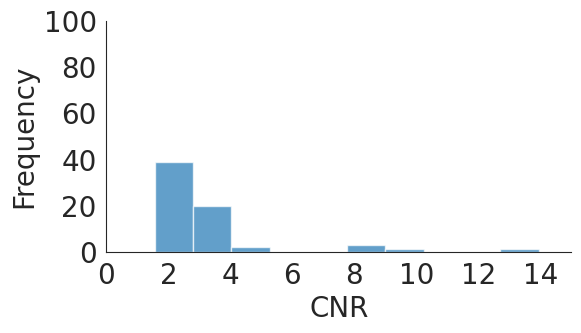

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")
cnr_values = [cnr for _, cnr in cnr_results]
plt.figure(figsize=(6, 3))
plt.hist(cnr_values, bins=10, alpha=0.7)
#plt.title("CNR Distribution for Duke dataset")
plt.xlim(0, 15)
plt.ylim(0, 100)
plt.xlabel("CNR", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
sns.despine()
output_path = 'CNR_Kmeans_Duke.pdf'
#plt.axis('off')
plt.savefig(output_path, format='pdf',bbox_inches='tight', dpi=300)
plt.show()






In [4]:
import os
import numpy as np
from sklearn.cluster import KMeans


folder_path = 'UMNData/train/images'


#output_file = "cnr_results.txt"


cnr_results = []

# Iterate through all files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith(".npy"):
        file_path = os.path.join(folder_path, file_name)

        img = np.load(file_path)
        print(f"Processing {file_name}...")
        # Flatten image for clustering
        pixels = img.flatten().reshape(-1, 1)

        kmeans = KMeans(n_clusters=2, n_init=10, random_state=42).fit(pixels)
        segmented_labels = kmeans.labels_.reshape(img.shape)

        roi = img[segmented_labels == 1]
        background = img[segmented_labels == 0]

        S1 = np.mean(roi)
        S2 = np.mean(background)

        # Calculate noise (standard deviation of background)
        back_sigma = np.std(background)
        roi_sigma = np.std(roi)


        if back_sigma != 0 or roi_sigma!=0:  # Avoid division by zero
            CNR = abs(S1 - S2) / np.sqrt(roi_sigma**2 + back_sigma**2)
        else:
            CNR = float('inf')  # Assign infinity if sigma is 0

        cnr_results.append((file_name, CNR))

"""        print(f"File: {file_name}, CNR: {CNR}")


with open(output_file, "w") as f:
    f.write("File Name\tCNR\n")
    for file_name, CNR in cnr_results:
        f.write(f"{file_name}\t{CNR:.4f}\n")

print(f"CNR calculations completed. Results saved to {output_file}.")"""


Processing 14_13.npy...
Processing 12_24.npy...
Processing 12_06.npy...
Processing 8_21.npy...
Processing 4_05.npy...
Processing 17_13.npy...
Processing 6_15.npy...
Processing 1_07.npy...
Processing 10_04.npy...
Processing 5_11.npy...
Processing 13_03.npy...
Processing 3_21.npy...
Processing 11_14.npy...
Processing 3_16.npy...
Processing 13_10.npy...
Processing 15_18.npy...
Processing 11_19.npy...
Processing 17_02.npy...
Processing 18_20.npy...
Processing 17_07.npy...
Processing 10_19.npy...
Processing 14_17.npy...
Processing 17_00.npy...
Processing 4_22.npy...
Processing 1_23.npy...
Processing 7_03.npy...
Processing 0_05.npy...
Processing 13_01.npy...
Processing 1_08.npy...
Processing 9_12.npy...
Processing 12_04.npy...
Processing 15_06.npy...
Processing 17_08.npy...
Processing 3_12.npy...
Processing 1_00.npy...
Processing 17_12.npy...
Processing 16_20.npy...
Processing 9_14.npy...
Processing 0_13.npy...
Processing 8_03.npy...
Processing 14_02.npy...
Processing 2_23.npy...
Processing 

'        print(f"File: {file_name}, CNR: {CNR}")\n\n\nwith open(output_file, "w") as f:\n    f.write("File Name\tCNR\n")\n    for file_name, CNR in cnr_results:\n        f.write(f"{file_name}\t{CNR:.4f}\n")\n\nprint(f"CNR calculations completed. Results saved to {output_file}.")'

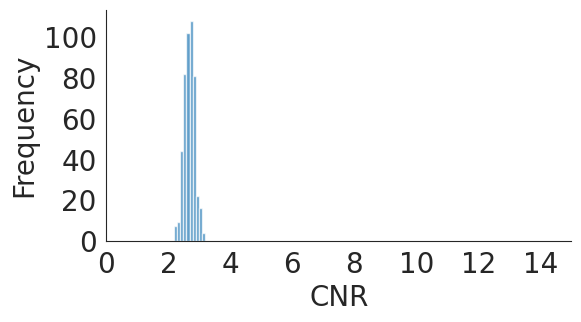

In [14]:
import matplotlib.pyplot as plt


sns.set_style("white")
cnr_values = [cnr for _, cnr in cnr_results]
plt.figure(figsize=(6, 3))
plt.hist(cnr_values, bins=10, alpha=0.7)
#plt.title("CNR Distribution for UMN dataset")
plt.xlim(0, 15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("CNR", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.xlabel("CNR")
sns.despine()
output_path = 'CNR_Kmeans_UMN.pdf'
#plt.axis('off')
plt.savefig(output_path, format='pdf',bbox_inches='tight', dpi=300)
plt.show()




In [34]:
# theresholding


import numpy as np
import matplotlib.pyplot as plt

import cv2


def apply_otsu_thresholding_to_npy(npy_file_path):
  """
  Applies Otsu's thresholding to an image loaded from an .npy file.

  Args:
    npy_file_path: Path to the .npy file containing the image data.

  Returns:
    A tuple containing:
      - The calculated threshold value.
      - The thresholded image as a NumPy array.
  """


  img_array = np.load(npy_file_path)


  img = img_array


  img_uint8 = (img * 255).astype(np.uint8)

  # Apply Otsu's thresholding
  ret, thresholded_img = cv2.threshold(img_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

  return ret, thresholded_img,img_uint8




folder_path = 'UMNData/train/images'




cnr_results = []

# Iterate through all files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith(".npy"):
        file_path = os.path.join(folder_path, file_name)
        threshold_value, thresholded_image ,image= apply_otsu_thresholding_to_npy(file_path)
        print(f"Otsu's Threshold Value for {file_name}: {threshold_value}")
        """plt.figure(figsize=(10, 5))

        # Original Image
        plt.subplot(1, 2, 1)
        plt.title("Original Image")
        plt.imshow(image, cmap='gray')
        plt.axis('off')

        # Thresholded Image
        plt.subplot(1, 2, 2)
        plt.title("Thresholded Image (Otsu's)")
        plt.imshow(thresholded_image, cmap='gray')
        plt.axis('off')

        plt.show()"""
        signal_region = image[image >= threshold_value]  # Pixels >= threshold
        noise_region = image[image < threshold_value]   # Pixels < threshold


        if len(signal_region) > 0 and len(noise_region) > 0:  # Avoid division by zero
            mu_s = np.mean(signal_region)
            sigma_s = np.std(signal_region)
            mu_n = np.mean(noise_region)
            sigma_n = np.std(noise_region)

            cnr = abs(mu_s - mu_n) / np.sqrt(sigma_s**2 + sigma_n**2)
        else:
            cnr = 0  # Default to 0 if one of the regions is empty
        cnr_results.append(cnr)











Otsu's Threshold Value for 14_13.npy: 126.0
Otsu's Threshold Value for 12_24.npy: 119.0
Otsu's Threshold Value for 12_06.npy: 122.0
Otsu's Threshold Value for 8_21.npy: 128.0
Otsu's Threshold Value for 4_05.npy: 117.0
Otsu's Threshold Value for 17_13.npy: 127.0
Otsu's Threshold Value for 6_15.npy: 115.0
Otsu's Threshold Value for 1_07.npy: 112.0
Otsu's Threshold Value for 10_04.npy: 124.0
Otsu's Threshold Value for 5_11.npy: 118.0
Otsu's Threshold Value for 13_03.npy: 119.0
Otsu's Threshold Value for 3_21.npy: 123.0
Otsu's Threshold Value for 11_14.npy: 115.0
Otsu's Threshold Value for 3_16.npy: 127.0
Otsu's Threshold Value for 13_10.npy: 119.0
Otsu's Threshold Value for 15_18.npy: 128.0
Otsu's Threshold Value for 11_19.npy: 116.0
Otsu's Threshold Value for 17_02.npy: 121.0
Otsu's Threshold Value for 18_20.npy: 119.0
Otsu's Threshold Value for 17_07.npy: 125.0
Otsu's Threshold Value for 10_19.npy: 127.0
Otsu's Threshold Value for 14_17.npy: 127.0
Otsu's Threshold Value for 17_00.npy: 1

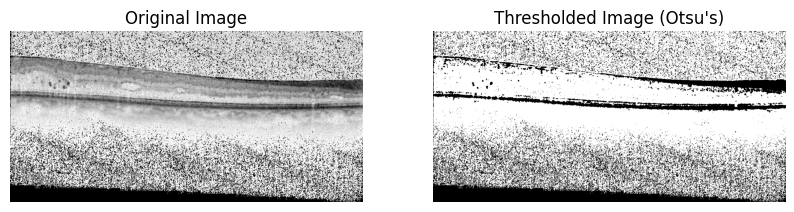

In [10]:
 # plot one sample from UMN dataset

 plt.figure(figsize=(10, 5))


plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Thresholded Image (Otsu's)")
plt.imshow(thresholded_image, cmap='gray')
plt.axis('off')

plt.show()

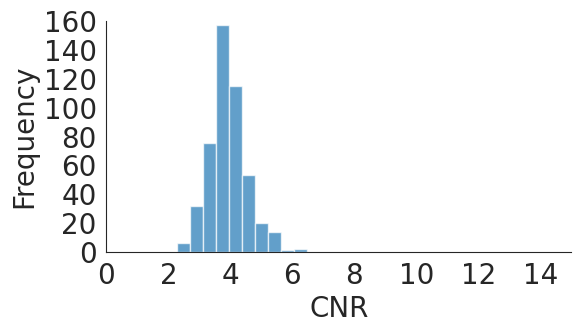

In [35]:
import matplotlib.pyplot as plt

cnr_values = [cnr for cnr in cnr_results]
plt.figure(figsize=(6, 3))
plt.hist(cnr_values, bins=10, alpha=0.7)
#plt.title("CNR Distribution for UMN dataset")
plt.xlabel("CNR")
plt.xlim(0, 15)
plt.ylim(0,160)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("CNR", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.xlabel("CNR")
sns.despine()
output_path = 'CNR_Thr_UMN.pdf'
#plt.axis('off')
plt.savefig(output_path, format='pdf',bbox_inches='tight', dpi=300)
plt.show()

plt.show()



In [36]:
# theresholding


import numpy as np
import matplotlib.pyplot as plt

import cv2


def apply_otsu_thresholding_to_npy(npy_file_path):
  """
  Applies Otsu's thresholding to an image loaded from an .npy file.

  Args:
    npy_file_path: Path to the .npy file containing the image data.

  Returns:
    A tuple containing:
      - The calculated threshold value.
      - The thresholded image as a NumPy array.
  """


  img_array = np.load(npy_file_path)


  img = img_array


  img_uint8 = (img * 255).astype(np.uint8)

  # Apply Otsu's thresholding
  ret, thresholded_img = cv2.threshold(img_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

  return ret, thresholded_img,img_uint8




folder_path = 'DukeData/train/images'




cnr_results_duke = []

# Iterate through all files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith(".npy"):
        file_path = os.path.join(folder_path, file_name)
        threshold_value, thresholded_image ,image= apply_otsu_thresholding_to_npy(file_path)
        print(f"Otsu's Threshold Value for {file_name}: {threshold_value}")
        """plt.figure(figsize=(10, 5))

        # Original Image
        plt.subplot(1, 2, 1)
        plt.title("Original Image")
        plt.imshow(image, cmap='gray')
        plt.axis('off')

        # Thresholded Image
        plt.subplot(1, 2, 2)
        plt.title("Thresholded Image (Otsu's)")
        plt.imshow(thresholded_image, cmap='gray')
        plt.axis('off')

        plt.show()"""
        signal_region = image[image >= threshold_value]  # Pixels >= threshold
        noise_region = image[image < threshold_value]   # Pixels < threshold


        if len(signal_region) > 0 and len(noise_region) > 0:  # Avoid division by zero
            mu_s = np.mean(signal_region)
            sigma_s = np.std(signal_region)
            mu_n = np.mean(noise_region)
            sigma_n = np.std(noise_region)

            cnr = abs(mu_s - mu_n) / np.sqrt(sigma_s**2 + sigma_n**2)
        else:
            cnr = 0  # Default to 0 if one of the regions is empty
        cnr_results_duke.append(cnr)











Otsu's Threshold Value for Subject_04_10.npy: 116.0
Otsu's Threshold Value for Subject_06_09.npy: 115.0
Otsu's Threshold Value for Subject_04_08.npy: 117.0
Otsu's Threshold Value for Subject_06_05.npy: 113.0
Otsu's Threshold Value for Subject_05_07.npy: 118.0
Otsu's Threshold Value for Subject_04_00.npy: 114.0
Otsu's Threshold Value for Subject_05_00.npy: 116.0
Otsu's Threshold Value for Subject_01_09.npy: 116.0
Otsu's Threshold Value for Subject_06_00.npy: 117.0
Otsu's Threshold Value for Subject_05_10.npy: 124.0
Otsu's Threshold Value for Subject_04_02.npy: 119.0
Otsu's Threshold Value for Subject_06_02.npy: 114.0
Otsu's Threshold Value for Subject_04_04.npy: 117.0
Otsu's Threshold Value for Subject_02_06.npy: 112.0
Otsu's Threshold Value for Subject_06_10.npy: 116.0
Otsu's Threshold Value for Subject_05_04.npy: 114.0
Otsu's Threshold Value for Subject_02_03.npy: 113.0
Otsu's Threshold Value for Subject_03_08.npy: 117.0
Otsu's Threshold Value for Subject_02_00.npy: 116.0
Otsu's Thres

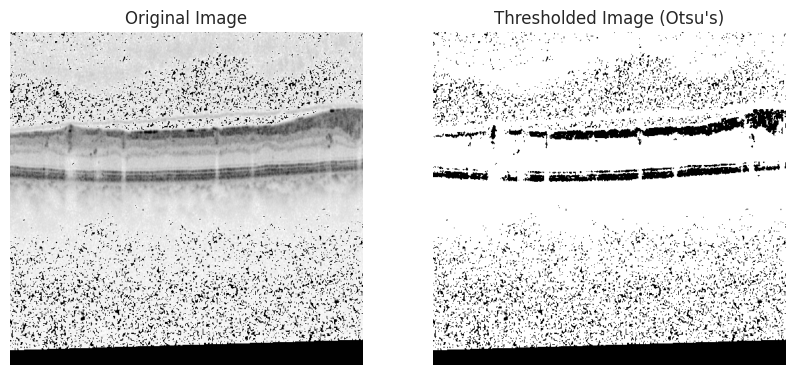

In [27]:
 # plot one sample from UMN dataset

 plt.figure(figsize=(10, 5))


plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Thresholded Image (Otsu's)")
plt.imshow(thresholded_image, cmap='gray')
plt.axis('off')

plt.show()

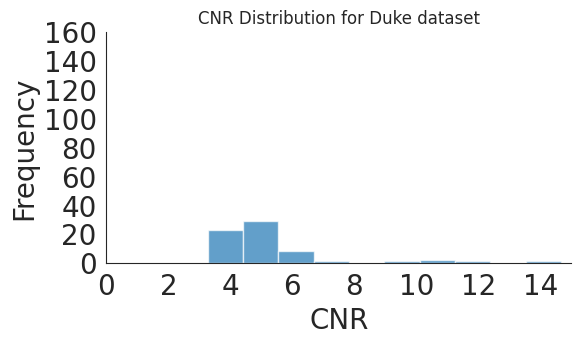

In [37]:
import matplotlib.pyplot as plt

cnr_values = [cnr for cnr in cnr_results_duke]
plt.figure(figsize=(6, 3))
plt.hist(cnr_values, bins=10, alpha=0.7)
plt.title("CNR Distribution for Duke dataset")
plt.xlabel("CNR")
plt.xlim(0, 15)
plt.ylim(0, 160)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("CNR", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.xlabel("CNR")
sns.despine()
output_path = 'CNR_thr_duke.pdf'
#plt.axis('off')
plt.savefig(output_path, format='pdf',bbox_inches='tight', dpi=300)
plt.show()

plt.show()






In [1]:
# during train
import pandas as pd
df=pd.read_csv('model_results_fixed_epsilon_mae.csv')

In [7]:
df= df.iloc[-1,:]

In [4]:
df.columns

Index(['Model_Name', 'Learning_Rate', 'Batch_Size', 'Training_Loss',
       'Validation_Loss', 'dice_all', 'Validation_Dice', 'Privacy_Epsilons',
       'max_grad_norm', 'noise_multiplier', 'iterations', 'dataset', 'mae',
       'per_layer_all_list'],
      dtype='object')

In [8]:
type(df['Validation_Dice'])

numpy.float64

In [16]:
s= df['per_layer_all_list']

In [17]:
import ast

my_list = ast.literal_eval(s)
print(my_list)
print(type(my_list))


[0.0, 0.00784373345474402, 0.006902070250362158, 0.00660472580542167, 0.00733816126982371, 0.009386480941126743, 0.005436410506566365, 0.005623794160783291, 0.004219831665977836]
<class 'list'>
